# ML Model Comparison (Tier 2)
This notebook trains and compares 5 traditional Machine Learning models to serve as the Tier 2 filter.
The models evaluate Flow features and predict if the flow is Benign or an Attack.

In [1]:
import os
import pickle
import time

import lightgbm as lgb
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

ROOT = os.path.dirname(os.getcwd()) if "ml_lab" in os.getcwd() else os.getcwd()
if not ROOT.endswith("AI_Security_Graph"):
    ROOT = os.path.join(ROOT, "AI_Security_Graph")
DATA_FILE = os.path.join(ROOT, "ml_lab", "dataset_100k.csv")
MODEL_OUT = os.path.join(ROOT, "ml_lab", "tier_2_model.pkl")

## 1. Load and Prepare Dataset

[*] Loading dataset from /home/binhchuoiz/Projects/Thesis/AI_Security_Graph/ml_lab/dataset_100k.csv...


Dataset Shape: (100000, 76)
Target Distribution: [20000 80000] (0: Benign, 1: Attack)


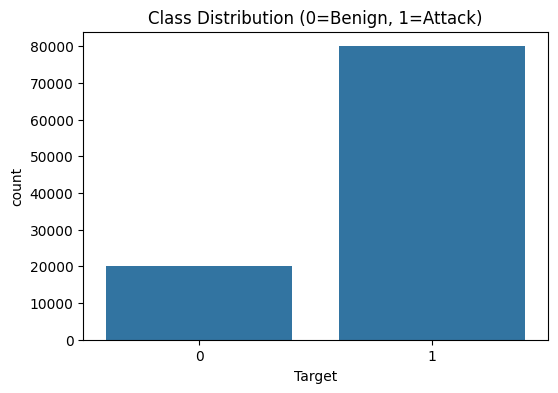

In [2]:
print(f"[*] Loading dataset from {DATA_FILE}...")
df = pd.read_csv(DATA_FILE)

y = df["Target"].values
exclude = [
    "Dst Port",
    "Protocol",
    "Timestamp",
    "Flow ID",
    "Src IP",
    "Src Port",
    "Dst IP",
    "Stage",
    "Label",
    "Target",
]
features = [c for c in df.columns if c not in exclude]

for c in features:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

X = df[features].values
feature_names = features

print(f"Dataset Shape: {X.shape}")
print(f"Target Distribution: {np.bincount(y)} (0: Benign, 1: Attack)")

# Plot Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Target", data=df)
plt.title("Class Distribution (0=Benign, 1=Attack)")
plt.show()

## 2. Train/Test Split and Scaling

In [3]:
# --- CHIA 3 TẬP: TRAIN (70%) - VAL (10%) - TEST/THI (20%) ---
# Đã trộn đều 4 loại dữ liệu (CICIDS, DAPT, Zero-day, Adversarial) trong data tổng

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)  # 0.125 * 0.8 = 0.1

print(f"[*] Kích thước Train: {len(X_train)}")
print(f"[*] Kích thước Val (Test nội bộ): {len(X_val)}")
print(f"[*] Kích thước Test (Tập THI): {len(X_test)}")


print("[*] Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

[*] Kích thước Train: 70000
[*] Kích thước Val (Test nội bộ): 10000
[*] Kích thước Test (Tập THI): 20000
[*] Scaling features...


## 3. Train and Evaluate 5 Models

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=20),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
}

results = []
confusion_matrices = {}
best_f1 = 0
best_model_name = ""
best_model_obj = None

for name, model in models.items():
    print(f"[*] Training {name}...")

    start_time = time.time()

    model_obj = model

    model_obj.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    # Validation
    y_val_pred = model_obj.predict(X_val_scaled)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)

    # Test
    start_time = time.time()
    y_test_pred = model_obj.predict(X_test_scaled)
    inference_time = (time.time() - start_time) / len(X_test_scaled)

    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec = recall_score(y_test, y_test_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_test_pred)
    confusion_matrices[name] = cm

    tn, fp, fn, tp = cm.ravel() if len(cm.ravel()) == 4 else (0, 0, 0, 0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    results.append(
        {
            "Model": name,
            "Val F1 (In-Dist)": round(val_f1, 4),
            "Test F1": round(f1, 4),
            "Test Precision": round(prec, 4),
            "Test Recall": round(rec, 4),
            "Test FPR": round(fpr, 4),
            "Train Time (s)": round(train_time, 2),
            "Inference (ms/sample)": round(inference_time * 1000, 6),
        }
    )

    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_model_obj = model_obj

# --- Ghi nhận lên MLflow ---
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5001"))
mlflow.set_experiment("Sentinel_ML_Tier2_Training")

with mlflow.start_run(run_name="ML_Tier2_Training_Run"):
    mlflow.log_param("dataset_size", len(X))
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("test_size", len(X_test))

    for r in results:
        m = r["Model"]
        # Prefix the metrics with model name for easy comparison in MLflow UI
        mlflow.log_metric(f"{m}_Val_F1", r["Val F1 (In-Dist)"])
        mlflow.log_metric(f"{m}_Test_F1", r["Test F1"])
        mlflow.log_metric(f"{m}_Test_Precision", r["Test Precision"])
        mlflow.log_metric(f"{m}_Test_Recall", r["Test Recall"])
        mlflow.log_metric(f"{m}_Inference_ms", r["Inference (ms/sample)"])

    mlflow.log_param("best_model", best_model_name)
    mlflow.log_metric("best_test_f1", best_f1)

[*] Training Logistic Regression...


[*] Training Decision Tree...


[*] Training Random Forest...


[*] Training XGBoost...


[*] Training LightGBM...
[LightGBM] [Info] Number of positive: 56000, number of negative: 14000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005912 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12856
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.800000 -> initscore=1.386294
[LightGBM] [Info] Start training from score 1.386294


/home/binhchuoiz/Projects/Thesis/AI_Security_Graph/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/binhchuoiz/Projects/Thesis/AI_Security_Graph/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🏃 View run ML_Tier2_Training_Run at: http://localhost:5001/#/experiments/5/runs/9f7594c416614d5a94e2d85cd076988f
🧪 View experiment at: http://localhost:5001/#/experiments/5


## 4. Comparison Results & Visualization

,Model,Val F1 (In-Dist),Test F1,Test Precision,Test Recall,Test FPR,Train Time (s),Inference (ms/sample)
4,LightGBM,0.9682,0.9666,0.9774,0.9559,0.0882,1.48,0.000380
3,XGBoost,0.9643,0.9634,0.9873,0.9406,0.0482,4.92,0.000777
1,Decision Tree,0.9609,0.9582,0.9683,0.9482,0.1240,1.17,0.000095
2,Random Forest,0.9593,0.9578,0.9660,0.9497,0.1338,0.59,0.003423
0,Logistic Regression,0.9516,0.9506,0.9529,0.9483,0.1875,1.70,0.000090


/tmp/ipykernel_1334613/2757283200.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Test F1", y="Model", data=df_res, palette="viridis")


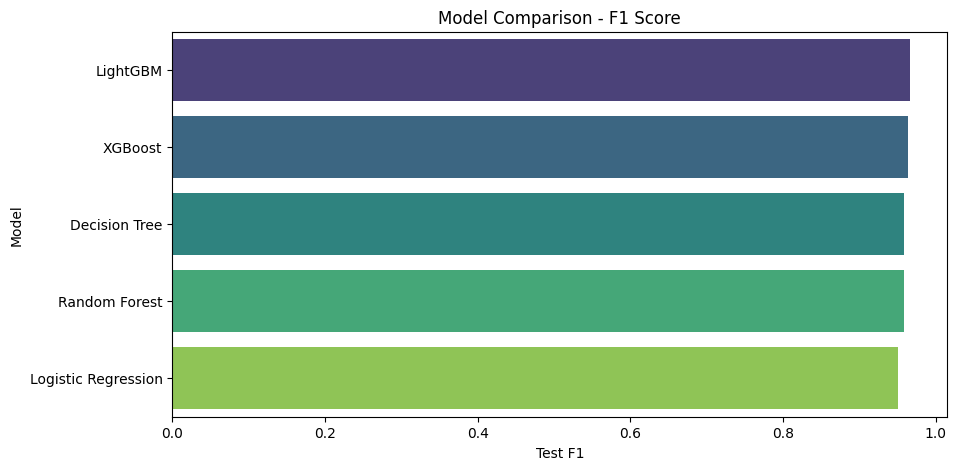

/tmp/ipykernel_1334613/2757283200.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Inference (ms/sample)", y="Model", data=df_res, palette="magma")


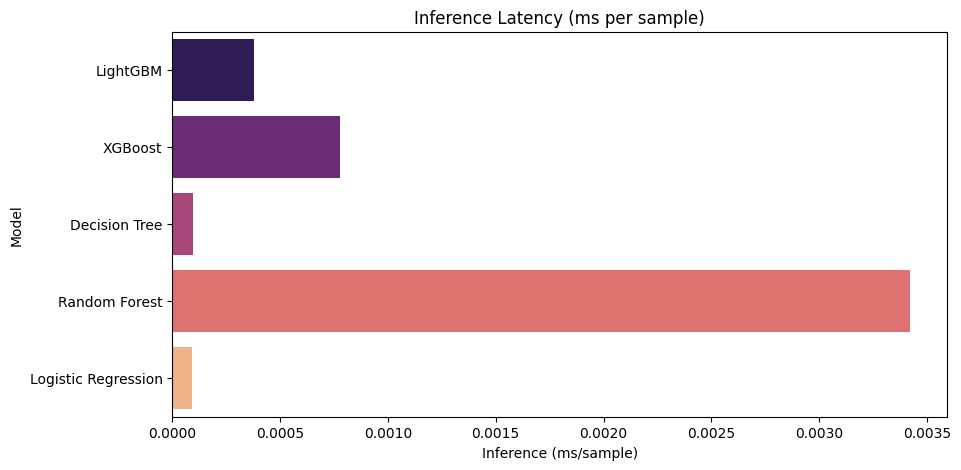

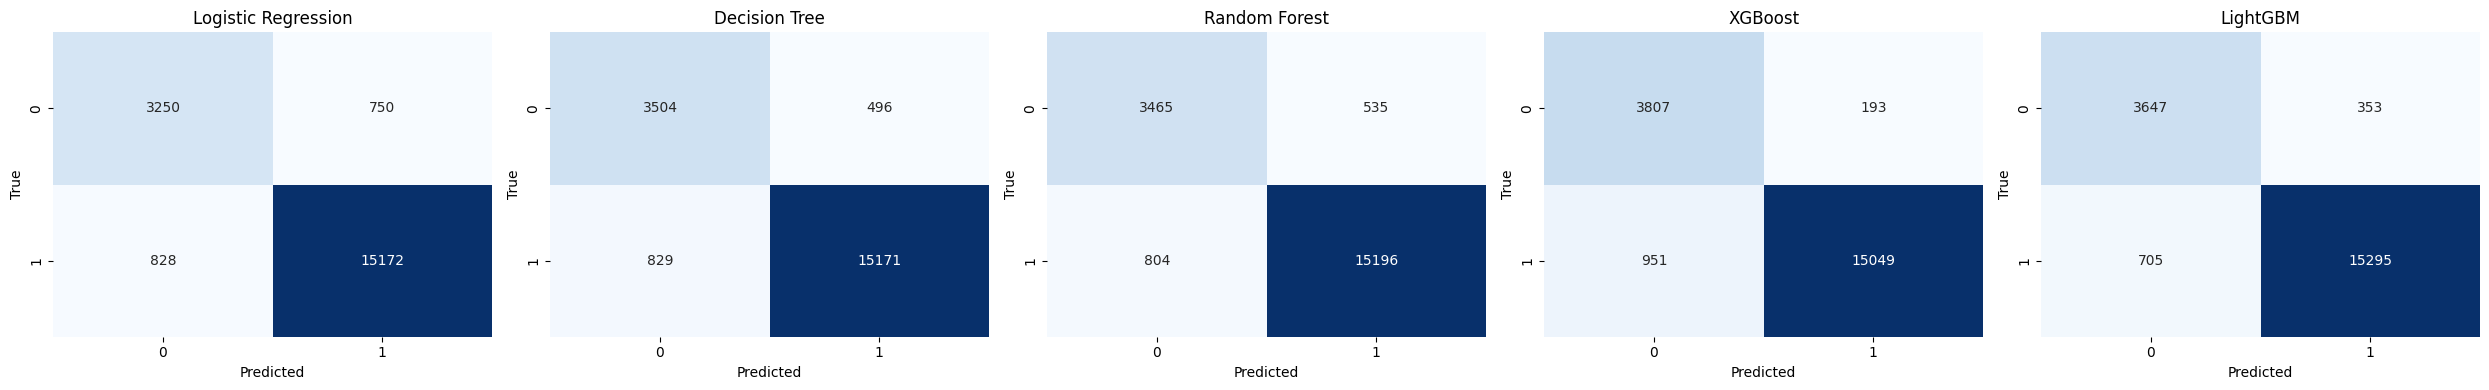

In [5]:
df_res = pd.DataFrame(results).sort_values(by="Test F1", ascending=False)
try:
    from IPython.display import display

    display(df_res)
except ImportError:
    print(df_res.to_markdown(index=False))

# Plot F1-Score
plt.figure(figsize=(10, 5))
sns.barplot(x="Test F1", y="Model", data=df_res, palette="viridis")
plt.title("Model Comparison - F1 Score")
plt.show()

# Plot Inference Time
plt.figure(figsize=(10, 5))
sns.barplot(x="Inference (ms/sample)", y="Model", data=df_res, palette="magma")
plt.title("Inference Latency (ms per sample)")
plt.show()

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

## 5. Export the Best Pipeline

In [6]:
print(f"[+] Best Model: {best_model_name} (F1: {best_f1:.4f})")

pipeline = {"scaler": scaler, "model": best_model_obj, "features": feature_names}

with open(MODEL_OUT, "wb") as f:
    pickle.dump(pipeline, f)
print(f"[*] Saved Tier 2 Pipeline to {MODEL_OUT}")

[+] Best Model: LightGBM (F1: 0.9666)
[*] Saved Tier 2 Pipeline to /home/binhchuoiz/Projects/Thesis/AI_Security_Graph/ml_lab/tier_2_model.pkl
